<a href="https://colab.research.google.com/github/oluwapelumi1/ACCESS-SAP-DATA-Science-Track/blob/main/Week3_Session6_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Week3_Session6_Data_Visualization**
 **Objectives**

---

using the dataset:[Retail Sales Dataset](https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset?resource=download)

*   Create at least 4 visualizations that communicate a single business story (e.g., trends or performance comparisons).

*   Push notebook and visuals to GitHub



In [47]:
#Import Necesssary Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Make plots appear in notebook
%matplotlib inline

#Suppress warnings for Cleaner output
import warnings
warnings.filterwarnings('ignore')

In [48]:
#Load the dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/retail_sales_dataset.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
#Get an Idea of the dataset
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [51]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


#**BAR CHARTS - Comparing Categories**

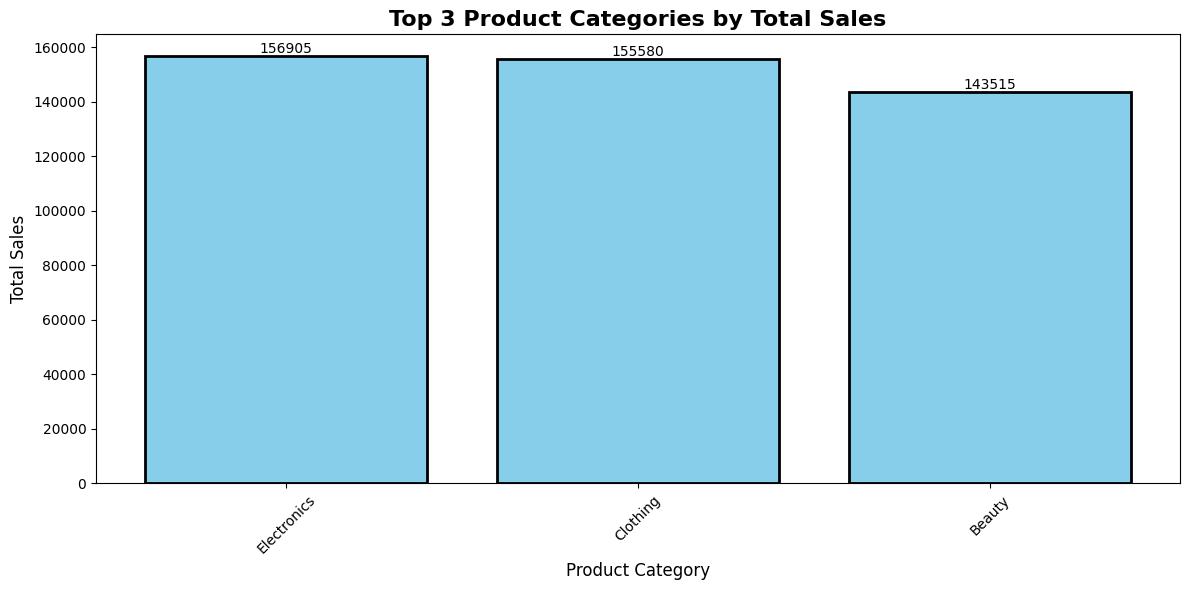

In [52]:
#Calculate the sum of 'Total Amount' for each 'Product Category'
product_category_sales = df.groupby('Product Category')['Total Amount'].sum().reset_index()

#Get the top 3 Product Category by 'Total Amount'
top_3 = product_category_sales.sort_values('Total Amount', ascending=False).head(3)

#Method 1 - Matplotlib
plt.figure(figsize=(12, 6)) #Set the chart size. Width = 12 inches and height = 6 inches

plt.bar( x= top_3['Product Category'],
         height= top_3['Total Amount'],
         color = 'skyblue',
         edgecolor = 'black',
         linewidth = 2
        )
plt.title('Top 3 Product Categories by Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)

#Add value labels on top of bars
for index, value in enumerate(top_3['Total Amount']):
    plt.text(x=index, y=value, s=f'{value}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

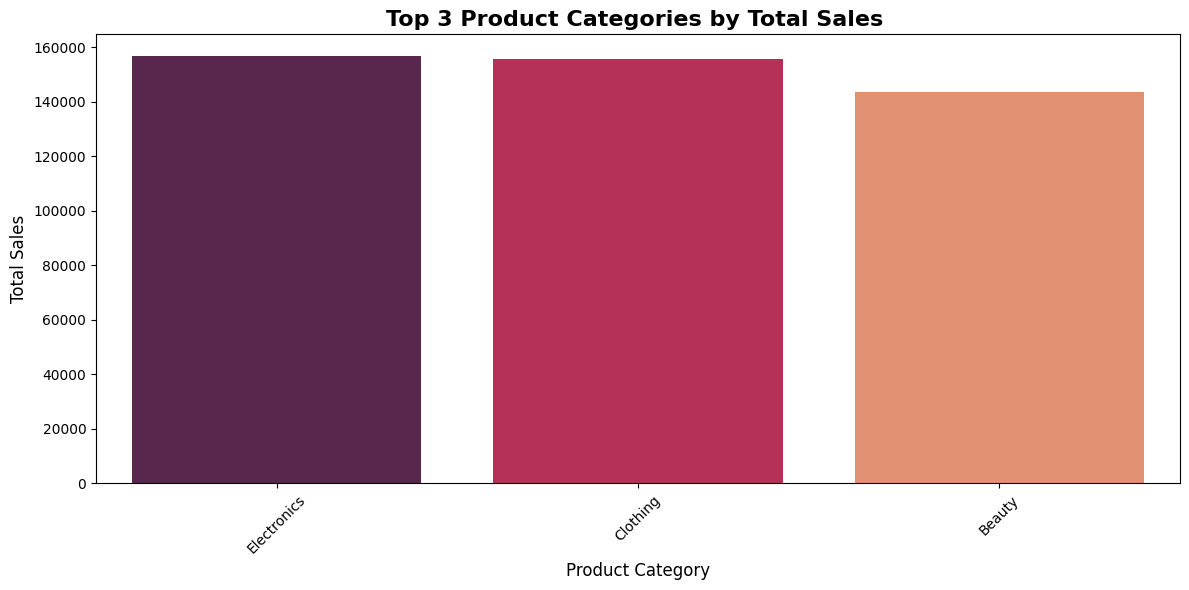

In [53]:
#Seaborn
plt.figure(figsize =(12,6))
sns.barplot(data =top_3,
            x ='Product Category',
            y ='Total Amount',
            palette = 'rocket'
            )
plt.title('Top 3 Product Categories by Total Sales ', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**HISTOGRAMS - Understanding Distributions**

In [54]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


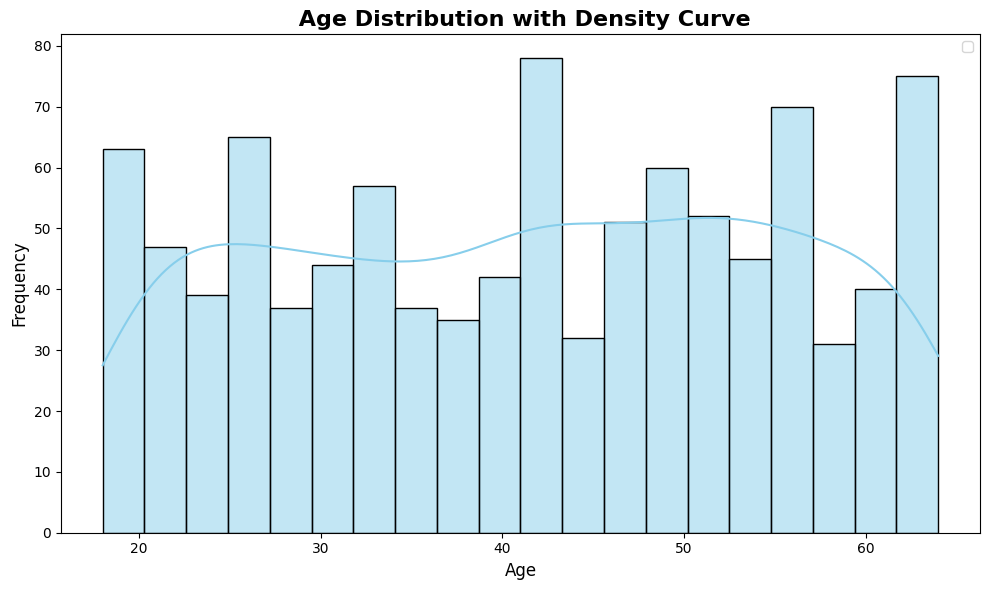

In [55]:
plt.figure(figsize=(10, 6))

# Histogram with smooth curve overlay
sns.histplot(data=df,
             x='Age',
             bins=20,
             kde=True,  # Add smooth density curve
             color='skyblue',
             edgecolor='black')

plt.title(' Age Distribution with Density Curve',
          fontsize=16,
          fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# **BOXPLOTS - Spotting Outliers and Comparing Groups**

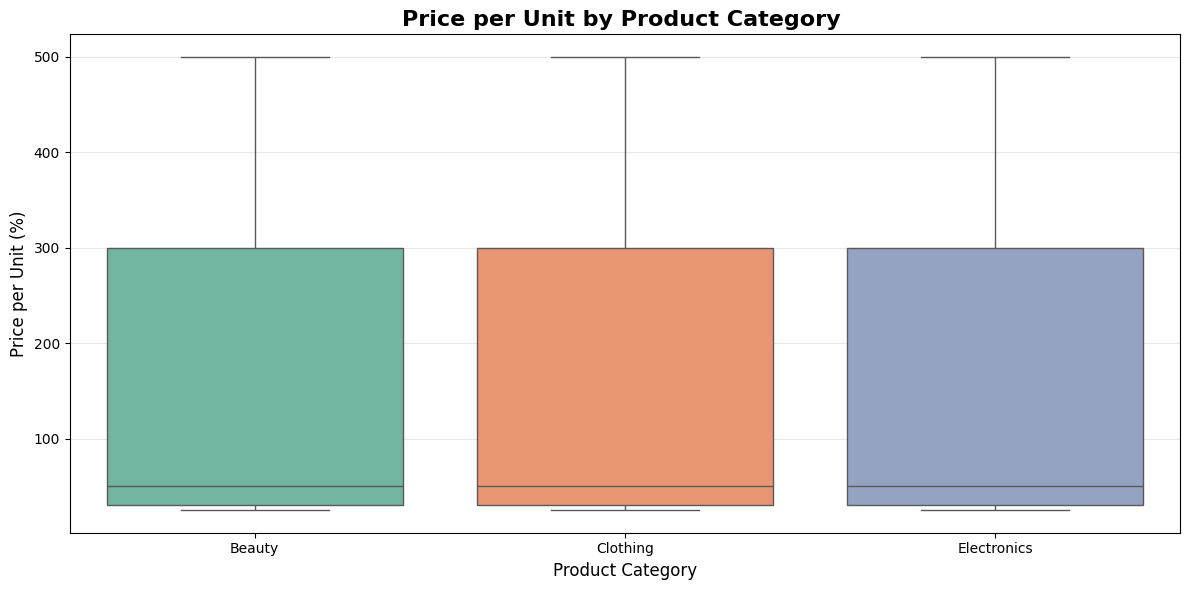

In [44]:
plt.figure(figsize=(12, 6))

# Boxplot comparing Product category across Price per unit
sns.boxplot(data=df,
            x='Product Category',
            y='Price per Unit',
            palette='Set2')

plt.title('Price per Unit by Product Category ',
          fontsize=16,
          fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Price per Unit (%)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [45]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


# **TIME SERIES PLOTS- Tracking Changes Over Time**

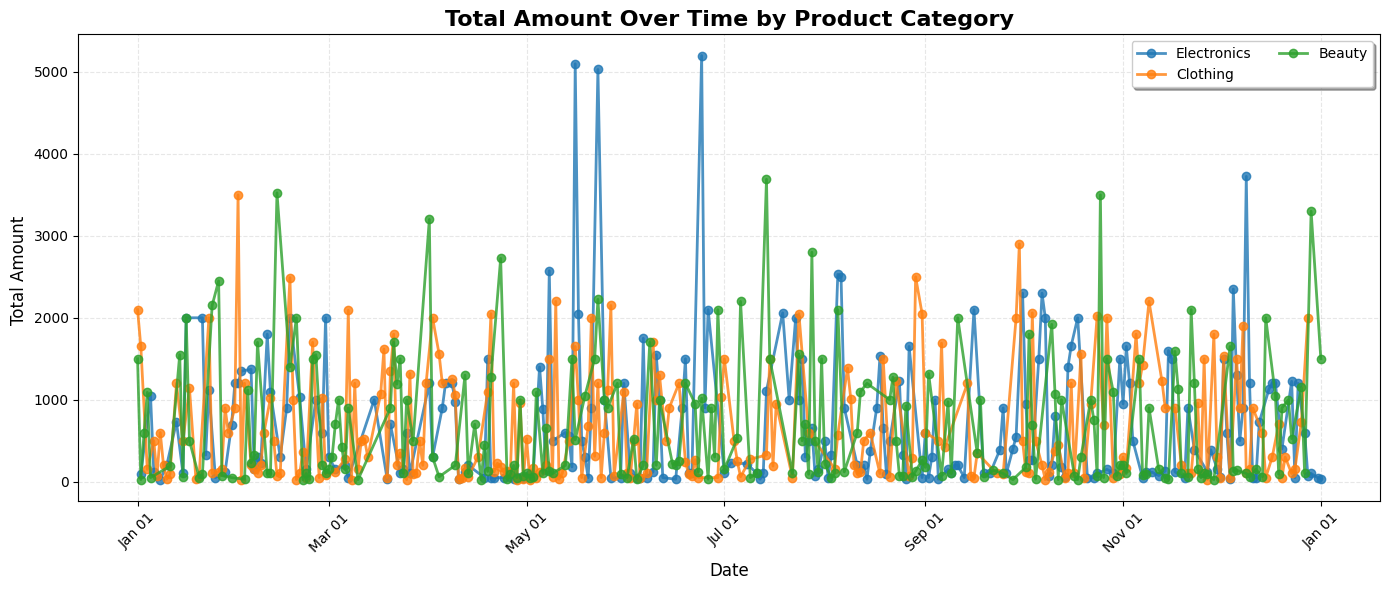

In [46]:
# Basic time series line plot

# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate data to get Total Amount over time by Product Category
df_time_series = df.groupby(['Date', 'Product Category'])['Total Amount'].sum().reset_index()

# Select a few product categories to visualize (e.g., top 5 by overall sales)
# First, find the top product categories by overall sales
overall_sales_by_category = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
product_category_sample = overall_sales_by_category.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))

for product_category in product_category_sample:
    product_category_data = df_time_series[df_time_series['Product Category'] == product_category]
    ax.plot(product_category_data['Date'],
            product_category_data['Total Amount'], # Changed from Index_Value
            marker='o',
            linewidth=2,
            label=product_category,
            alpha=0.8)

ax.set_title('Total Amount Over Time by Product Category',
             fontsize=16,
             fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Amount ', fontsize=12)
ax.legend(loc='best', frameon=True, shadow=True, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--')

# Format dates nicely
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()